<a href="https://colab.research.google.com/github/brianvngan/IMPACTassignments/blob/main/ImpactSpringAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [3]:
!pip install keras-unet

In [4]:
from keras_unet.models import custom_unet

-----------------------------------------
keras-unet init: TF version is >= 2.0.0 - using `tf.keras` instead of `Keras`
-----------------------------------------


In [5]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz


--2026-04-01 00:36:21--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-04-01 00:36:22--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  11.4MB/s    in 84s     

2026-04-01 00:37:47 (8.95 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-04-01 00:37:47--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [6]:
import os
from PIL import Image

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

names = sorted([f[:-4] for f in os.listdir('./images') if f.endswith('.jpg')])

images = np.array([np.array(Image.open(f'./images/{n}.jpg').convert('L').resize((300,300))) for n in names], dtype=np.float32) / 255.0
masks  = np.array([(np.array(Image.open(f'./annotations/trimaps/{n}.png').resize((300,300))) == 1).astype(np.float32) for n in names])

In [8]:
# PAD IMAGES to 320x320
X_train = images[:170]
y_train = masks[:170]
X_train = np.pad(X_train[..., None], ((0,0),(10,10),(10,10),(0,0)))
y_train = np.pad(y_train[..., None], ((0,0),(10,10),(10,10),(0,0)))

X_test = images[170:]
y_test = masks[170:]
X_test = np.pad(X_test[..., None], ((0,0),(10,10),(10,10),(0,0)))
y_test = np.pad(y_test[..., None], ((0,0),(10,10),(10,10),(0,0)))

In [16]:
#
# 2. NETWORK
#
model = custom_unet(
    input_shape=(320, 320, 1),
    dropout=0.2
)
model.compile(loss='binary_crossentropy')

In [24]:
#
# 3. TRAIN
#
from keras.callbacks import ModelCheckpoint, EarlyStopping

model_filename = 'segm_model_v3.h5'
callback_checkpoint = ModelCheckpoint(
    model_filename,
    verbose=1,
    monitor='val_loss',
    save_best_only=True,
)

callback_earlystopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

history = model.fit(X_train, y_train, validation_split=0.1, epochs=50,
                    callbacks=[callback_checkpoint, callback_earlystopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1329
Epoch 1: val_loss improved from None to 0.47369, saving model to segm_model_v3.h5



Epoch 1: finished saving model to segm_model_v3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1405 - val_loss: 0.4737
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1337
Epoch 2: val_loss did not improve from 0.47369
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1455 - val_loss: 0.5199
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1440
Epoch 3: val_loss did not improve from 0.47369
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1505 - val_loss: 0.6726
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1409
Epoch 4: val_loss did not improve from 0.47369
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1327 - val_loss: 0.4918
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1084
Epoch 5: val_loss improved from 0.47369 to 0.46010, saving model to segm_model_v3.h5



Epoch 5: finished saving model to segm_model_v3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1137 - val_loss: 0.4601
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1380
Epoch 6: val_loss improved from 0.46010 to 0.42206, saving model to segm_model_v3.h5



Epoch 6: finished saving model to segm_model_v3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1551 - val_loss: 0.4221
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1299
Epoch 7: val_loss did not improve from 0.42206
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1301 - val_loss: 0.4420
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1204
Epoch 8: val_loss did not improve from 0.42206
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1154 - val_loss: 0.4446
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1086
Epoch 9: val_loss did not improve from 0.42206
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1171 - val_loss: 0.4494
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1284
Epoch 10: val_loss did not improve from 0.42206
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1373 - val_loss: 0.5508
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1197
Epoch 11: val_loss did not improve from 0.42206
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4


Epoch 15: finished saving model to segm_model_v3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1331 - val_loss: 0.3897
Epoch 16/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1084
Epoch 16: val_loss improved from 0.38970 to 0.37776, saving model to segm_model_v3.h5



Epoch 16: finished saving model to segm_model_v3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1087 - val_loss: 0.3778
Epoch 17/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1434
Epoch 17: val_loss did not improve from 0.37776
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1339 - val_loss: 0.4757
Epoch 18/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1008
Epoch 18: val_loss did not improve from 0.37776
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1020 - val_loss: 0.4626
Epoch 19/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1084
Epoch 19: val_loss did not improve from 0.37776
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1157 - val_loss: 0.4107
Epoch 20/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1138
Epoch 20: val_loss did not improve from 0.37776
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1142 - val_loss: 0.3969
Epoch 21/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0988
Epoch 21: val_loss did not improve from 0.37776
5/5 ━━━━━━━━━━━━━━━━━━

In [25]:
#
# 4. PREDICT
#
y_pred = model.predict(X_test)

226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


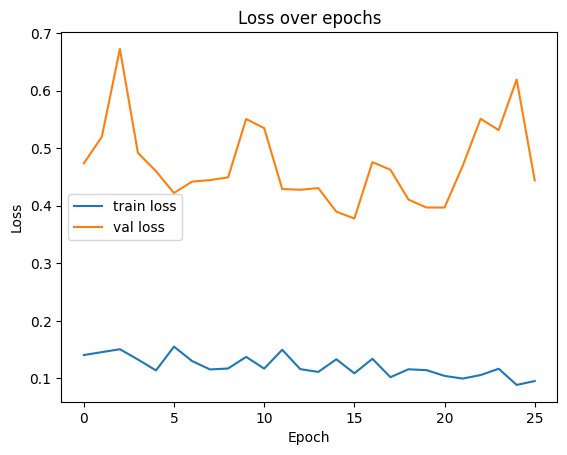

In [28]:
# LOSS PLOT
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

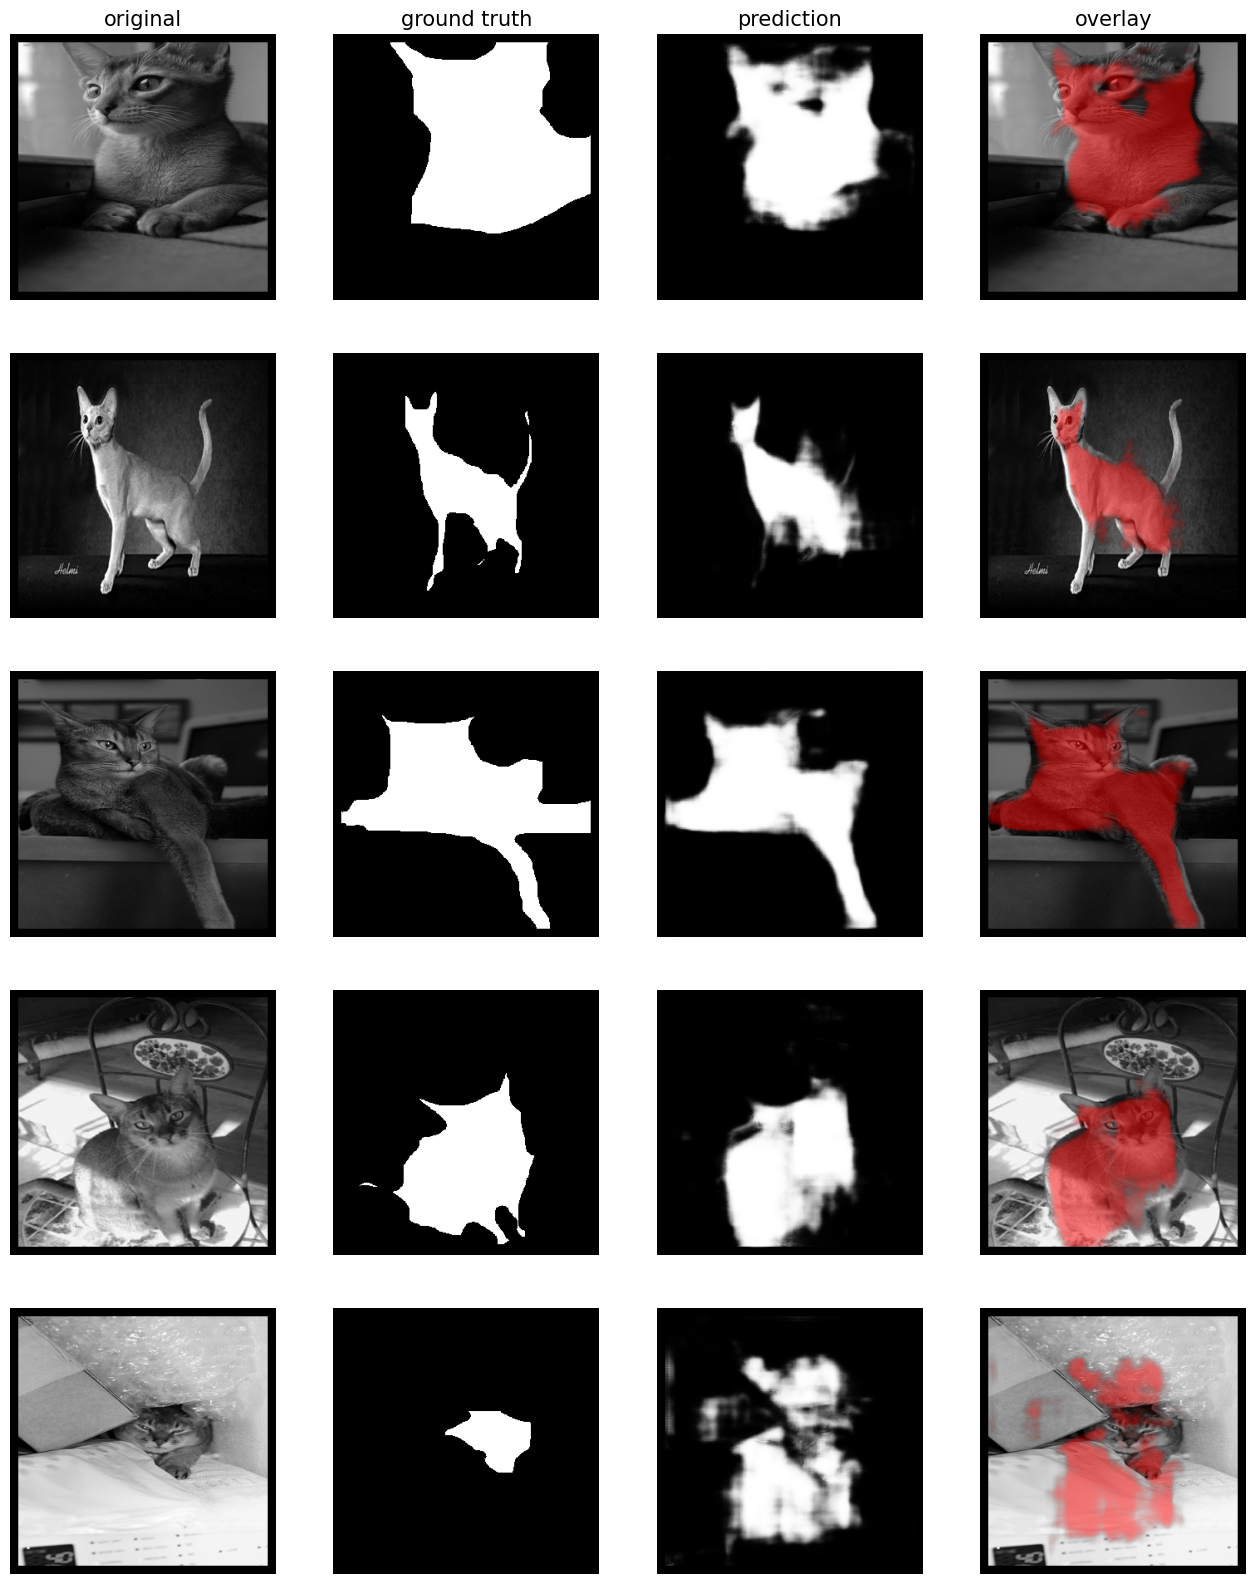

In [29]:
from keras_unet.utils import plot_imgs
plot_imgs(org_imgs=X_test, mask_imgs=y_test, pred_imgs=y_pred, nm_img_to_plot=5)